# Adult Income - Model Training & Evaluation

This notebook trains, tunes, and evaluates multiple machine learning classifiers to predict income levels. It compares models based on Accuracy, F1 Score, and ROC-AUC, ultimately selecting the best-performing model and analyzing its feature importance to prevent overfitting.

## Contents
1. Load Data
2. Logistic Regression
3. K-Nearest Neighbors (KNN)
4. Decision Tree
5. Naive Bayes
6. Support Vector Machine (SVM)
7. Random Forest
8. Gradient Boosting
9. All Models Comparison
10. Choosing Best Model & Overfitting Check

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

In [3]:
sns.set_theme(style='darkgrid')

# 1. Load Data

In [4]:
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

X_train = train.drop('income', axis=1)
y_train = train['income']

X_test = test.drop('income', axis=1)
y_test = test['income']

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23276 entries, 0 to 23275
Data columns (total 53 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   num__age                                   23276 non-null  float64
 1   num__education.num                         23276 non-null  float64
 2   num__capital.gain                          23276 non-null  float64
 3   num__capital.loss                          23276 non-null  float64
 4   num__hours.per.week                        23276 non-null  float64
 5   cat__workclass_Federal-gov                 23276 non-null  float64
 6   cat__workclass_Private                     23276 non-null  float64
 7   cat__workclass_Self-emp-inc                23276 non-null  float64
 8   cat__workclass_Self-emp-not-inc            23276 non-null  float64
 9   cat__workclass_State/Local-gov             23276 non-null  float64
 10  cat__workclass_Unknown

In [5]:
evaluations = {'Logistic Regression': [],
               'KNN': [],
               'Decision Tree': [],
               'Naive Bayes': [],
               'SVM': [],
               'Random Forest': [],
               'Gradient Boosting': []
               }

# 2. Logistic Regression

In [6]:
logistic_params = {"C": [0.01, 0.1, 1, 10, 100]}

logistic_grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    logistic_params,
    cv=5,
    scoring="f1"
)

logistic_grid.fit(X_train, y_train)

print(f"Best Logistic Regression Parameters: {logistic_grid.best_params_}")
print(f"Best Logistic Regression CV F1: {logistic_grid.best_score_ * 100:.2f}")

Best Logistic Regression Parameters: {'C': 1}
Best Logistic Regression CV F1: 65.83


In [7]:
logistic_model = LogisticRegression(max_iter=1000, class_weight="balanced", **logistic_grid.best_params_)

logistic_cv = cross_val_score(logistic_model , X_train , y_train , cv=5)

logistic_model.fit(X_train , y_train)
logistic_pred = logistic_model.predict(X_test)

evaluations['Logistic Regression'].append(accuracy_score(y_test ,logistic_pred))
evaluations['Logistic Regression'].append(f1_score(y_test ,logistic_pred))

Evaluation

Accuracy: 80.58
              precision    recall  f1-score   support

           0       0.93      0.80      0.86      4378
           1       0.58      0.82      0.68      1442

    accuracy                           0.81      5820
   macro avg       0.75      0.81      0.77      5820
weighted avg       0.84      0.81      0.82      5820



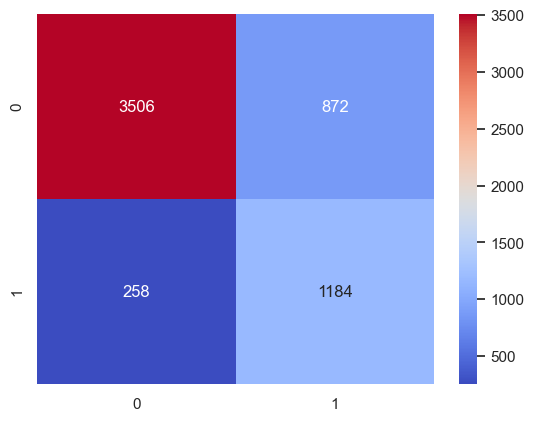

In [8]:
print(f"Accuracy: {evaluations['Logistic Regression'][0] * 100:.2f}")
print(classification_report(y_test , logistic_pred))

sns.heatmap(confusion_matrix(y_test , logistic_pred), annot=True, fmt='d', cmap='coolwarm')
plt.show()

# 3. KNN

In [9]:
knn_params = {
    "n_neighbors": [3, 5, 7, 9, 11]
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=5,
    scoring="f1"
)

knn_grid.fit(X_train, y_train)

print(f"Best KNN Parameters: {knn_grid.best_params_}")
print(f"Best KNN CV F1: {knn_grid.best_score_ * 100:.2f}")

Best KNN Parameters: {'n_neighbors': 7}
Best KNN CV F1: 63.56


In [10]:
knn_model = KNeighborsClassifier(**knn_grid.best_params_)

knn_cv = cross_val_score(knn_model , X_train , y_train , cv=5)

knn_model.fit(X_train , y_train)
knn_pred = knn_model.predict(X_test)

evaluations['KNN'].append(accuracy_score(y_test, knn_pred))
evaluations['KNN'].append(f1_score(y_test, knn_pred))

Evaluation

Accuracy: 83.04
              precision    recall  f1-score   support

           0       0.87      0.91      0.89      4378
           1       0.68      0.59      0.63      1442

    accuracy                           0.83      5820
   macro avg       0.78      0.75      0.76      5820
weighted avg       0.82      0.83      0.83      5820



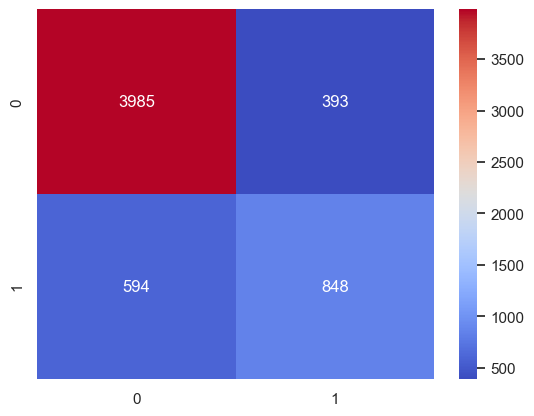

In [11]:
print(f"Accuracy: {evaluations['KNN'][0] * 100:.2f}")
print(classification_report(y_test, knn_pred))

sns.heatmap(confusion_matrix(y_test, knn_pred), annot=True, fmt='d', cmap='coolwarm')
plt.show()

# 4. Decision Tree

In [12]:
dt_params = {
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,
    scoring="f1"
)

dt_grid.fit(X_train, y_train)

print(f"Best Decision Tree Parameters: {dt_grid.best_params_}")
print(f"Best Decision Tree CV F1: {dt_grid.best_score_ * 100:.2f}")

Best Decision Tree Parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best Decision Tree CV F1: 67.98


In [13]:
dt_model = DecisionTreeClassifier(**dt_grid.best_params_, class_weight="balanced", random_state=42)

dt_cv = cross_val_score(dt_model, X_train, y_train, cv=5)

dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

evaluations['Decision Tree'].append(accuracy_score(y_test, dt_pred))
evaluations['Decision Tree'].append(f1_score(y_test, dt_pred))

Evaluation

Accuracy: 79.23
              precision    recall  f1-score   support

           0       0.94      0.77      0.85      4378
           1       0.55      0.86      0.67      1442

    accuracy                           0.79      5820
   macro avg       0.75      0.82      0.76      5820
weighted avg       0.85      0.79      0.80      5820



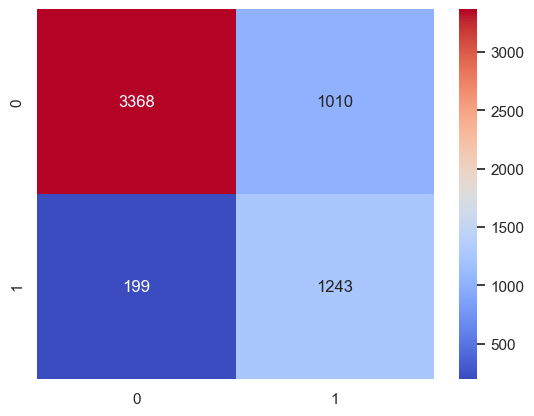

In [14]:
print(f"Accuracy: {evaluations['Decision Tree'][0] * 100:.2f}")
print(classification_report(y_test, dt_pred))

sns.heatmap(confusion_matrix(y_test, dt_pred), annot=True, fmt='d', cmap='coolwarm')
plt.show()

# 5. Naive Bayes

In [15]:
nb_params = {
    "var_smoothing": np.logspace(0, -9, num=10)
}

nb_grid = GridSearchCV(
    GaussianNB(),
    nb_params,
    cv=5,
    scoring="f1"
)

nb_grid.fit(X_train, y_train)

print(f"Best Naive Bayes Parameters: {nb_grid.best_params_}")
print(f"Best Naive Bayes CV F1: {nb_grid.best_score_ * 100:.2f}")

Best Naive Bayes Parameters: {'var_smoothing': np.float64(0.01)}
Best Naive Bayes CV F1: 65.24


In [16]:
nb_model = GaussianNB(**nb_grid.best_params_)

nb_cv = cross_val_score(nb_model, X_train, y_train, cv=5)

nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)

evaluations['Naive Bayes'].append(accuracy_score(y_test, nb_pred))
evaluations['Naive Bayes'].append(f1_score(y_test, nb_pred))

Evaluation

Accuracy: 78.23
              precision    recall  f1-score   support

           0       0.93      0.77      0.84      4378
           1       0.54      0.83      0.65      1442

    accuracy                           0.78      5820
   macro avg       0.74      0.80      0.75      5820
weighted avg       0.83      0.78      0.79      5820



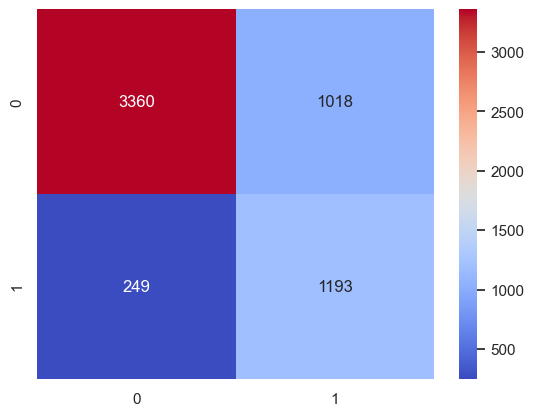

In [17]:
print(f"Accuracy: {evaluations['Naive Bayes'][0] * 100:.2f}")
print(classification_report(y_test, nb_pred))

sns.heatmap(confusion_matrix(y_test, nb_pred), annot=True, fmt='d', cmap='coolwarm')
plt.show()

# 6. SVM

In [18]:
svm_params = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"]
}

svm_grid = GridSearchCV(
    SVC(),
    svm_params,
    cv=5,
    scoring="f1",
)

svm_grid.fit(X_train, y_train)

print(f"Best SVM Parameters: {svm_grid.best_params_}")
print(f"Best SVM CV F1: {svm_grid.best_score_}")

Best SVM Parameters: {'C': 10, 'kernel': 'rbf'}
Best SVM CV F1: 0.6654919910114676


In [19]:
svm_model= SVC(class_weight="balanced", **svm_grid.best_params_)

svm_cv = cross_val_score(svm_model, X_train, y_train)

svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

evaluations['SVM'].append(accuracy_score(y_test, svm_pred))
evaluations['SVM'].append(f1_score(y_test, svm_pred))

Evaluation

Accuracy: 0.8042955326460481
              precision    recall  f1-score   support

           0       0.94      0.79      0.86      4378
           1       0.57      0.84      0.68      1442

    accuracy                           0.80      5820
   macro avg       0.75      0.82      0.77      5820
weighted avg       0.85      0.80      0.81      5820



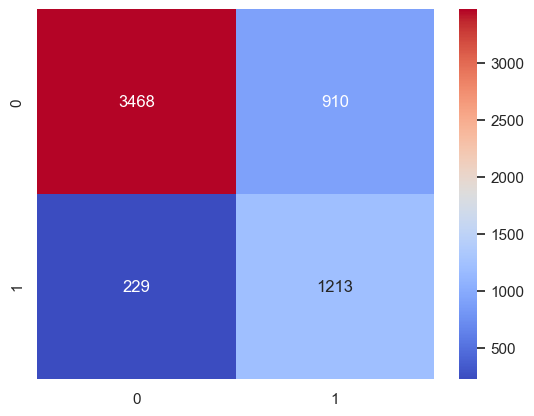

In [20]:
print(f"Accuracy: {evaluations['SVM'][0]}")
print(classification_report(y_test, svm_pred))

sns.heatmap(confusion_matrix(y_test, svm_pred), annot=True, fmt='d', cmap='coolwarm')
plt.show()

# 7. Random Forest

In [21]:
rf_params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print(f"Best Random Forest Parameters: {rf_grid.best_params_}")
print(f"Best Random Forest CV F1: {rf_grid.best_score_ * 100:.2f}")

Best Random Forest Parameters: {'max_depth': 20, 'n_estimators': 200}
Best Random Forest CV F1: 67.98


In [22]:
rf_model = RandomForestClassifier(random_state=42, class_weight="balanced", **rf_grid.best_params_, )

rf_cv = cross_val_score(rf_model, X_train, y_train, cv=5)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

evaluations['Random Forest'].append(accuracy_score(y_test, rf_pred))
evaluations['Random Forest'].append(f1_score(y_test, rf_pred))

Evaluation

Accuracy: 83.66
              precision    recall  f1-score   support

           0       0.93      0.85      0.89      4378
           1       0.64      0.79      0.71      1442

    accuracy                           0.84      5820
   macro avg       0.78      0.82      0.80      5820
weighted avg       0.85      0.84      0.84      5820



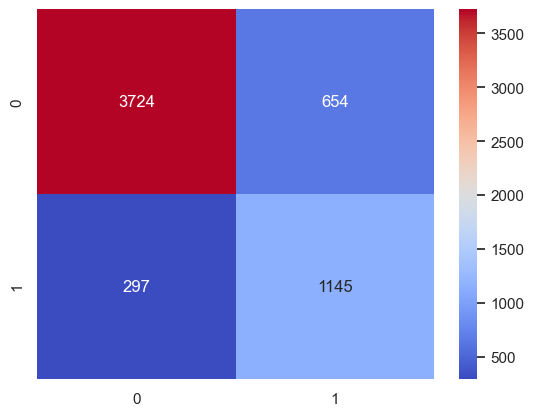

In [23]:
print(f"Accuracy: {evaluations['Random Forest'][0] * 100:.2f}")
print(classification_report(y_test, rf_pred))

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='coolwarm')
plt.show()

# 8. Gradient Boosting

In [6]:
gb_params = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, 7]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print(f"Best Gradient Boosting Parameters: {gb_grid.best_params_}")
print(f"Best Gradient Boosting CV F1: {gb_grid.best_score_ * 100:.2f}")

Best Gradient Boosting Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}
Best Gradient Boosting CV F1: 71.46


In [7]:
gb_model = GradientBoostingClassifier(random_state=42, **gb_grid.best_params_)

gb_cv = cross_val_score(gb_model, X_train, y_train, cv=5)

gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

evaluations['Gradient Boosting'].append(accuracy_score(y_test, gb_pred))
evaluations['Gradient Boosting'].append(f1_score(y_test, gb_pred))

Evaluation

Accuracy: 87.23
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      4378
           1       0.80      0.65      0.72      1442

    accuracy                           0.87      5820
   macro avg       0.84      0.80      0.82      5820
weighted avg       0.87      0.87      0.87      5820



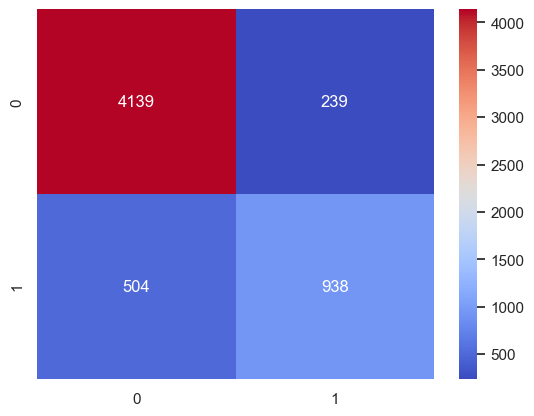

In [8]:
print(f"Accuracy: {evaluations['Gradient Boosting'][0] * 100:.2f}")
print(classification_report(y_test, gb_pred))

sns.heatmap(confusion_matrix(y_test, gb_pred), annot=True, fmt='d', cmap='coolwarm')
plt.show()

# All Models Comparison

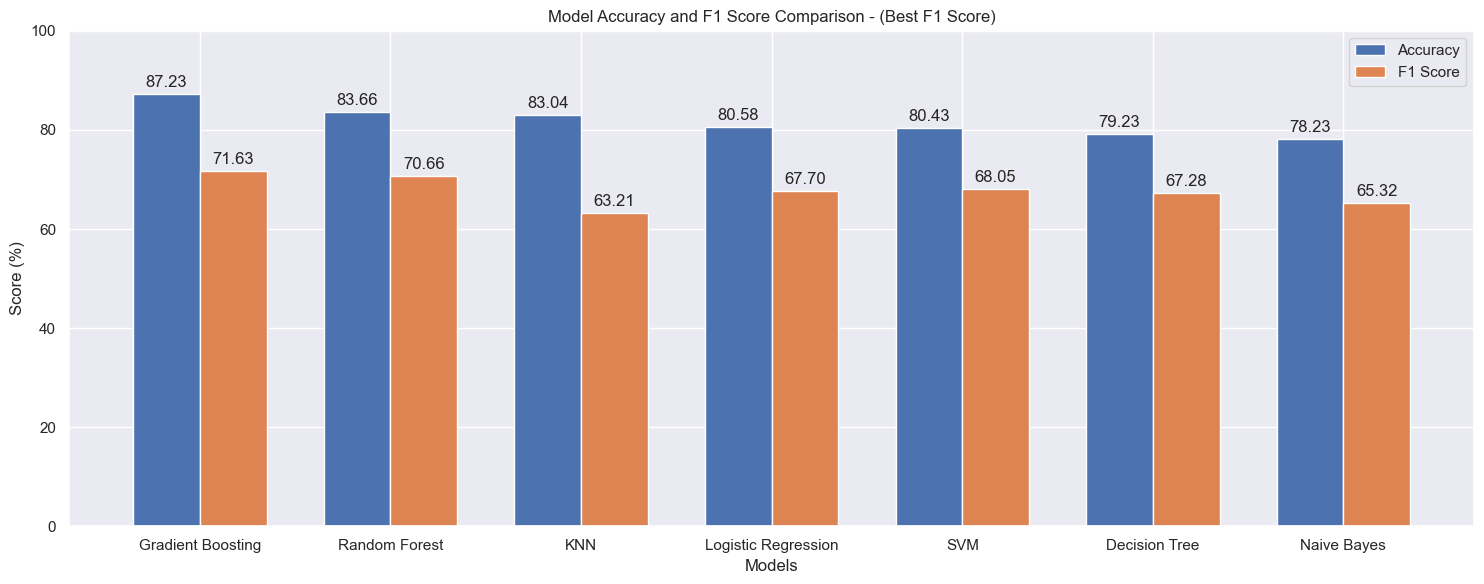

In [39]:
evaluated_models = evaluations.keys()

accuracies = np.array([
    evaluations[model][0] for model in evaluated_models
]) * 100

f1_scores = np.array([
    evaluations[model][1] for model in evaluated_models
]) * 100

# Create one DataFrame with both metrics
results = pd.DataFrame({
    "Model": evaluated_models,
    "Accuracy (%)": accuracies,
    "F1 Score (%)": f1_scores
})

# Sort by accuracy: highest to lowest
results = results.sort_values(by="Accuracy (%)", ascending=False)
results.to_csv('../data/models_best_f1.csv', index=False)

# Plot both metrics together
x = np.arange(len(results))
width = 0.35

plt.figure(figsize=(15, 6))

accuracy_bars = plt.bar(
    x - width / 2,
    results["Accuracy (%)"],
    width,
    label="Accuracy"
)
f1_bars = plt.bar(
    x + width / 2,
    results["F1 Score (%)"],
    width,
    label="F1 Score"
)

plt.bar_label(accuracy_bars, fmt="%.2f", padding=3)
plt.bar_label(f1_bars, fmt="%.2f", padding=3)

plt.xlabel("Models")
plt.ylabel("Score (%)")
plt.title("Model Accuracy and F1 Score Comparison - (Best F1 Score)")
plt.xticks(x, results["Model"])
plt.ylim(0, 100.1)
plt.legend()
plt.tight_layout()
plt.show()

# Choosing best model

Since `Gradient Boosting` achieved the highest Accuracy and F1 Score, it was selected as the final model.

## Checking overfitting

In [9]:
gb_train_pred = gb_model.predict(X_train)
gb_test_pred = gb_model.predict(X_test)

# Training scores
train_accuracy = accuracy_score(y_train, gb_train_pred)
train_f1 = f1_score(y_train, gb_train_pred)

# Test scores
test_accuracy = accuracy_score(y_test, gb_test_pred)
test_f1 = f1_score(y_test, gb_test_pred)


In [17]:
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy:     {test_accuracy * 100:.2f}%")

print()

print(f"Training F1 Score: {train_f1 * 100:.2f}%")
print(f"Test F1 Score:     {test_f1 * 100:.2f}%")

Training Accuracy: 88.00%
Test Accuracy:     87.23%

Training F1 Score: 73.90%
Test F1 Score:     71.63%


## ROC AUC Score

In [16]:
from sklearn.metrics import roc_auc_score

gb_test_proba = gb_model.predict_proba(X_test)[:, 1]

test_roc_auc = roc_auc_score(y_test, gb_test_proba)

print(f"Test ROC-AUC: {test_roc_auc * 100:.2f}%")

Test ROC-AUC: 92.70%


## Feature Importans

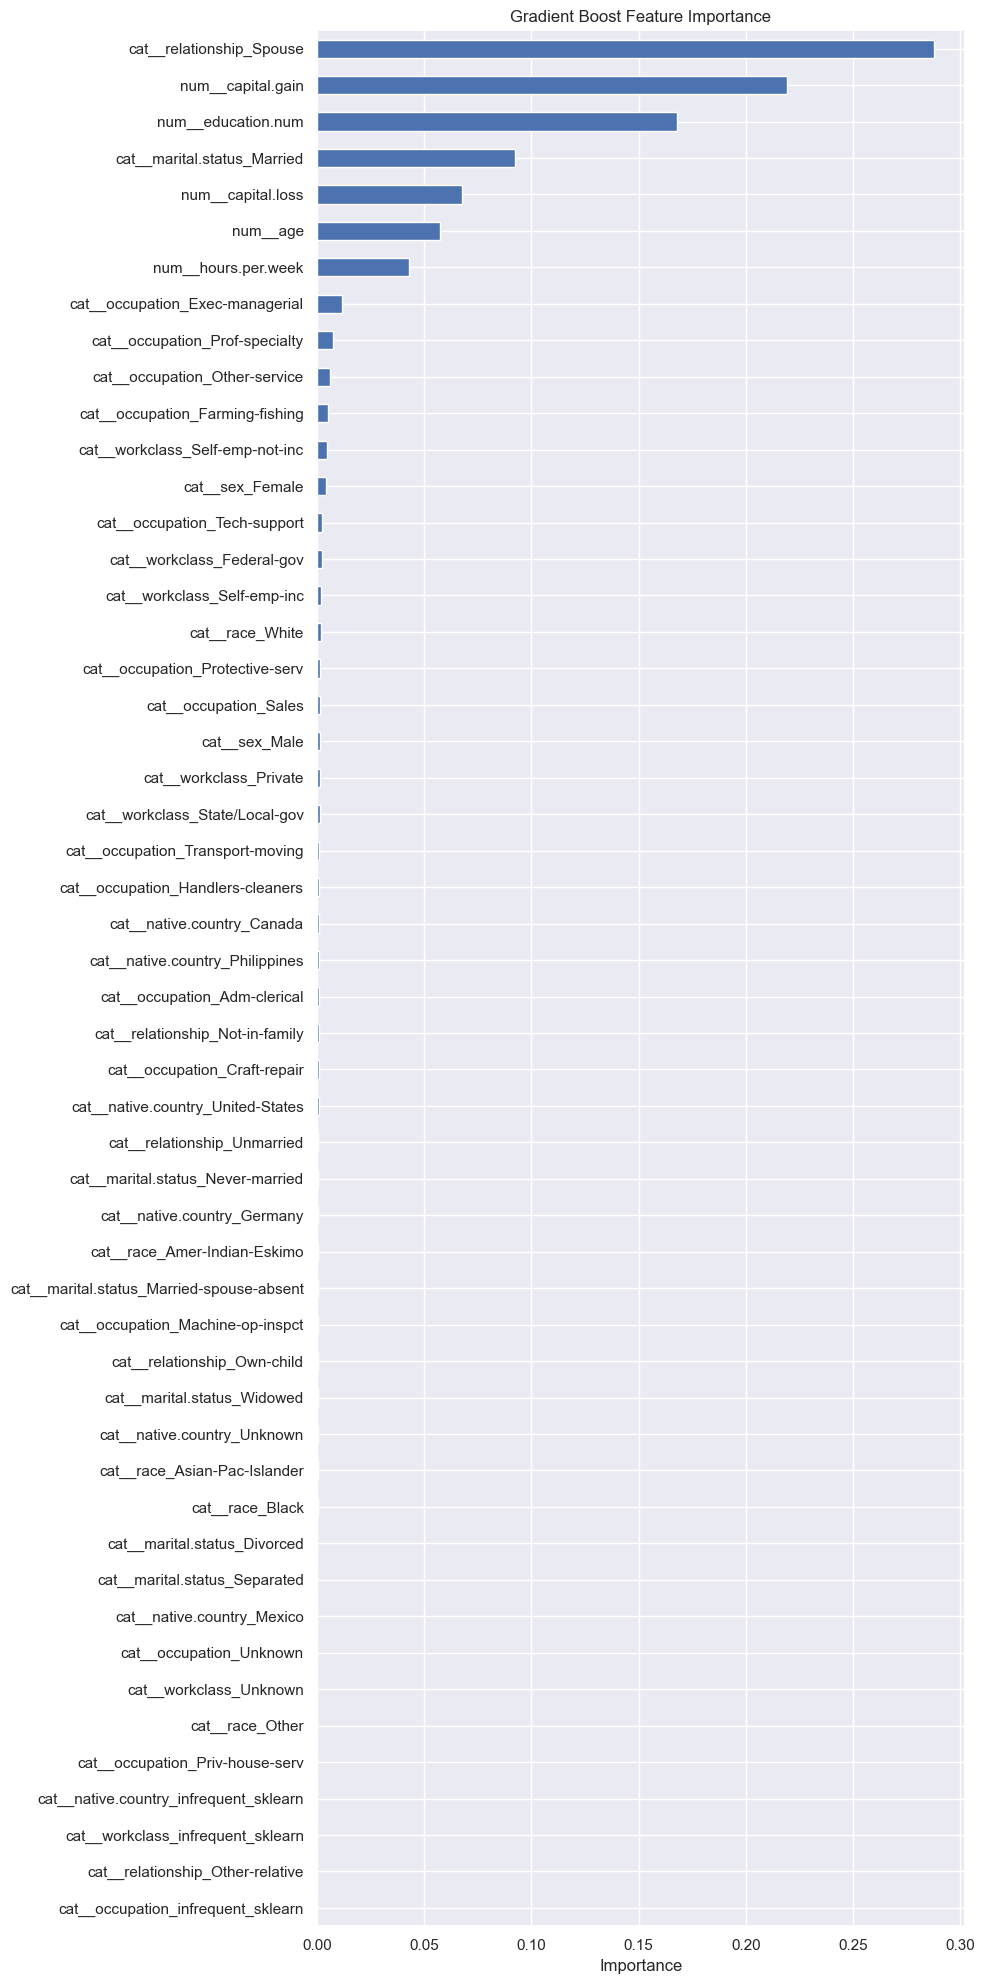

In [15]:
importances = pd.Series(gb_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 20))
importances.plot(kind="barh", color="#4C72B0")
plt.title("Gradient Boost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Save Model Weights

In [ ]:
import joblib

joblib.dump(gb_model, '../model/final_model_weights.pkl')

['../final_model_weights.pkl']

In [1]:
import sys
import sklearn
import numpy
import joblib

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)
print("numpy:", numpy.__version__)
print("joblib:", joblib.__version__)

Python: 3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]
scikit-learn: 1.7.2
numpy: 2.3.1
joblib: 1.5.2
